# Real-World Dataset Evaluation -- Bayesian Shrinkage Priors

**Objective**: Systematically benchmark all Bayesian and Frequentist regression models across five real-world datasets of varying dimensionality.

**Models**: OLS, Lasso CV, Ridge CV, ElasticNet CV, Bayesian Ridge, Bayesian Lasso, Bayesian ElasticNet, Horseshoe, Spike-and-Slab

**Datasets**: Diabetes (n=442, p=10), Predictors Large, Riboflavin (p>>n genomics), Arcene (p=10000), Communities & Crime

**Metrics**: RMSE, MAE, R^2, Adjusted R^2, LOO-CV, WAIC, Sparsity (% zero coefficients, F1 on support)


In [ ]:

# Cell 1 -- Imports & Configuration

import os, time, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import invgamma, invgauss

from sklearn.linear_model import (LinearRegression, LassoCV, RidgeCV,
                                  ElasticNetCV, BayesianRidge as SklearnBayesianRidge)
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import pymc as pm
import arviz as az
import pytensor.tensor as pt

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, Predictive, config_enumerate
from pyro.infer.autoguide import AutoNormal
from pyro import poutine

warnings.filterwarnings('ignore')
logging.getLogger('pymc').setLevel(logging.CRITICAL)
logging.getLogger('pytensor').setLevel(logging.CRITICAL)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 6),
                     'font.size': 11, 'axes.titlesize': 13})

# -- Global configuration --
SEED        = 42
N_ITER      = 10_000
BURN_IN     = 5_000
CI_ALPHA    = 0.05
TEST_SIZE   = 0.20
DATA_DIR    = 'Dataset'
RESULTS_DIR = 'real_world_eval_results'
PRESCREEN_MULT = 5   # keep top 5xn features (was 3 -- less signal loss)

# -- MCMC / VI tuning --
NUTS_DRAWS     = 4000     # posterior draws per chain
NUTS_TUNE      = 2000     # warmup / tuning steps per chain
NUTS_CHAINS    = 4        # number of independent chains
NUTS_ACCEPT    = 0.95     # target acceptance probability
ADVI_ITER      = 100_000  # ADVI variational iterations
ADVI_P_THRESH  = 250      # use ADVI when p (after screening) exceeds this

np.random.seed(SEED)
pyro.set_rng_seed(SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Configuration: SEED={SEED}, N_ITER={N_ITER}, BURN_IN={BURN_IN}')
print(f'  TEST_SIZE={TEST_SIZE}, PRESCREEN_MULT={PRESCREEN_MULT}, ADVI when p>{ADVI_P_THRESH}')
print(f'  NUTS: {NUTS_CHAINS} chains x {NUTS_DRAWS} draws, {NUTS_TUNE} tune, accept={NUTS_ACCEPT}')
print(f'  ADVI: {ADVI_ITER:,} iterations')
print(f'  PyMC {pm.__version__}, ArviZ {az.__version__}, Pyro {pyro.__version__}')
print('Imports complete ')


Configuration: SEED=42, N_ITER=10000, BURN_IN=5000
  TEST_SIZE=0.2, PRESCREEN_MULT=5, ADVI when p>250
  NUTS: 4 chains x 4000 draws, 2000 tune, accept=0.95
  ADVI: 100,000 iterations
  PyMC 5.25.1, ArviZ 0.23.4, Pyro 1.9.1
Imports complete 


## Section 2 -- Utility Functions


In [ ]:

# Cell 2 -- Shared Utility Functions


def count_near_zero(coef, threshold=1e-3):
    """Count coefficients effectively zero (|beta| < threshold)."""
    return int(np.sum(np.abs(coef) < threshold))

def prescreen_features(X, y, max_features):
    """Select top features by absolute marginal correlation with y.
    Returns (X_screened, selected_indices)."""
    n, p = X.shape
    if p <= max_features:
        return X, np.arange(p)
    corrs = np.abs(np.array([np.corrcoef(X[:, j], y)[0, 1]
                             for j in range(p)]))
    corrs = np.nan_to_num(corrs, 0.0)
    top_idx = np.argsort(corrs)[-max_features:]
    top_idx = np.sort(top_idx)
    return X[:, top_idx], top_idx

def map_coefs_back(coef_screened, selected_idx, p_full):
    """Map screened coefficients back to full-dimensional space."""
    coef_full = np.zeros(p_full)
    coef_full[selected_idx] = coef_screened
    return coef_full

def map_beta_samples_back(beta_samples, selected_idx, p_full):
    """Map posterior samples back to full-dimensional space."""
    S = beta_samples.shape[0]
    full = np.zeros((S, p_full))
    full[:, selected_idx] = beta_samples
    return full

def compute_loo_cv_sklearn(model_cls, model_kw, X, y, max_n=200):
    """LOO-CV via sklearn cross_val_score (capped for speed)."""
    n = X.shape[0]
    if n > max_n:
        idx = np.random.RandomState(SEED).choice(n, max_n, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y
    try:
        model = model_cls(**model_kw)
        scores = cross_val_score(model, X_sub, y_sub,
                                 cv=min(n, 10),
                                 scoring='neg_mean_squared_error')
        return -scores.mean()
    except Exception:
        return np.nan

print('Utilities defined (incl. feature prescreening, coef mapping)')

Utilities defined   (incl. feature prescreening, coef mapping)


## Section 3 -- Model Definitions

All models from `all_models.ipynb` plus Spike-and-Slab (Gibbs sampler from `synthetic_benchmark.ipynb`).


In [1]:

# Cell 3a -- FrequentistWrapper


class FrequentistWrapper:
    """Unified interface for sklearn linear models."""
    def __init__(self, model, name='Frequentist'):
        self.model = model
        self.name = name
        self.is_bayesian = False

    def fit(self, X, y):
        self.model.fit(X, y)
        self.coef_ = self.model.coef_.ravel()
        self.intercept_ = self.model.intercept_ if hasattr(self.model, 'intercept_') else 0
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_coefficients(self):
        return self.coef_

print('FrequentistWrapper ')

FrequentistWrapper 


In [ ]:

# Cell 3b -- BayesianRidge (sklearn Evidence Maximization)

# Uses sklearn.linear_model.BayesianRidge which implements the
# conjugate closed-form evidence maximization (MacKay 1992, Tipping 2001).
# Exact, fast for ANY p -- no MCMC needed. Returns posterior mean & variance.


class BayesianRidge:
    """Bayesian Ridge via sklearn's evidence maximization (Type-II ML)."""
    def __init__(self, name='Bayesian Ridge'):
        self.name = name
        self.is_bayesian = True

    def fit(self, X, y):
        n, p = X.shape
        self.model = SklearnBayesianRidge(
            max_iter=500, tol=1e-4,
            alpha_1=1e-6, alpha_2=1e-6,   # noise precision hyperpriors
            lambda_1=1e-6, lambda_2=1e-6,  # weight precision hyperpriors
            compute_score=True,
            fit_intercept=False  # data is already standardised
)
        self.model.fit(X, y)
        self.coef_ = self.model.coef_.ravel()

        # Generate posterior samples for WAIC computation
        # Posterior is N(m, sigma^2 Sigma) where Sigma = model.sigma_
        alpha = self.model.alpha_  # noise precision
        lambda_reg = self.model.lambda_  # weight precision
        sigma2 = 1.0 / alpha
        n_samples = min(N_ITER - BURN_IN, 2000)
        rng = np.random.RandomState(SEED + 100)

        # Posterior covariance: (alpha X'X + lam I)^{-1}
        if p <= n:
            A = alpha * (X.T @ X) + lambda_reg * np.eye(p)
            try:
                L = np.linalg.cholesky(A + 1e-8 * np.eye(p))
                samples = []
                for _ in range(n_samples):
                    z = rng.randn(p)
                    samples.append(self.coef_ + np.linalg.solve(L.T, z))
                self.beta_samples_ = np.array(samples)
            except np.linalg.LinAlgError:
                self.beta_samples_ = np.tile(self.coef_, (n_samples, 1))
        else:
            # Woodbury for p > n
            M = alpha * (X @ X.T) + lambda_reg * np.eye(n)
            try:
                L_M = np.linalg.cholesky(M + 1e-8 * np.eye(n))
                samples = []
                for _ in range(n_samples):
                    u = rng.randn(p) / np.sqrt(lambda_reg)
                    delta = rng.randn(n) / np.sqrt(alpha)
                    v = X @ u + delta
                    w = np.linalg.solve(L_M.T, np.linalg.solve(L_M, y - v))
                    beta_s = u + (1.0/lambda_reg) * (X.T @ w)
                    samples.append(beta_s)
                self.beta_samples_ = np.array(samples)
            except np.linalg.LinAlgError:
                self.beta_samples_ = np.tile(self.coef_, (n_samples, 1))

        self.sigma2_samples_ = np.full(n_samples, sigma2)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_coefficients(self):
        return self.coef_

print('BayesianRidge   (sklearn evidence maximization -- exact, any p)')

BayesianRidge   (sklearn evidence maximization -- exact, any p)


In [ ]:

# Cell 3c -- BayesianLasso (PyMC, Park & Casella 2008)

# Hierarchical Bayesian Lasso (Park & Casella 2008):
#   beta_j | tau^2_j, sigma^2 ~ N(0, sigma^2tau^2_j),  tau^2_j ~ Exp(lam^2/2)
# NON-CENTERED parameterization: beta_j = beta_raw_j x sigma x sqrttau^2_j
# -- eliminates funnel geometry for robust NUTS/ADVI convergence.
# ADVI for p > ADVI_P_THRESH, NUTS otherwise.
# Feature prescreening for p >> n.


class BayesianLasso:
    """Bayesian Lasso (Park & Casella 2008) -- non-centered, PyMC."""
    def __init__(self, name='Bayesian Lasso'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig

        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        lambda_init = float(np.sqrt(p / (2 * np.sum(y**2) + 1e-8)))

        with pm.Model():
            lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1,
                               initval=lambda_init)
            sigma = pm.HalfNormal("sigma", sigma=1.0)

            # Park & Casella (2008) scale-mixture + NON-CENTERED:
            # tau^2_j ~ Exp(lam^2/2),  beta_j = beta_raw_j x sigma x sqrttau^2_j
            tau_sq = pm.Exponential("tau_sq", lam=0.5 * lambda_**2, shape=p)
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta",
                                    beta_raw * sigma * pm.math.sqrt(tau_sq))

            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=NUTS_ACCEPT,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'],
                                      kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(
                beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('BayesianLasso   (Park & Casella 2008, non-centered, PyMC)')


BayesianLasso   (Park & Casella 2008, non-centered, PyMC)


In [ ]:

# Cell 3d -- BayesianElasticNet (PyMC, Li & Lin 2010)

# Bayesian Elastic Net -- hierarchical scale-mixture:
#   prior_sd_j = sigma x sqrt(1/lam_ridge + tau_j^2)
#   beta_j = beta_raw_j x prior_sd_j              (NON-CENTERED)
# tau_j ~ Exponential(lam_lasso)  -- local L1 shrinkage
# lam_ridge ~ Gamma                -- global L2 shrinkage
# Non-centered parameterization eliminates funnel geometry
# that caused 543 divergences in the centered version.
# ADVI for p > ADVI_P_THRESH, NUTS otherwise.


class BayesianElasticNet:
    """Bayesian ElasticNet (Li & Lin 2010) -- non-centered, PyMC."""
    def __init__(self, name='Bayesian ElasticNet'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig

        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        with pm.Model():
            # Hyperpriors on regularization strengths
            lambda_ridge = pm.Gamma("lambda_ridge", alpha=1.0, beta=1.0)
            lambda_lasso = pm.Gamma("lambda_lasso", alpha=0.1, beta=0.1)
            sigma = pm.HalfNormal("sigma", sigma=1.0)

            # Local L1 shrinkage via Exponential auxiliary
            tau_l1 = pm.Exponential("tau_l1", lam=lambda_lasso, shape=p)

            # Combined prior sd: L2 global + L1 local
            prior_sd = sigma * pm.math.sqrt(1.0 / lambda_ridge + tau_l1**2)

            # NON-CENTERED: beta = beta_raw x prior_sd
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta", beta_raw * prior_sd)

            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=NUTS_ACCEPT,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'],
                                      kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(
                beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('BayesianElasticNet   (Li & Lin 2010, NON-CENTERED, PyMC)')


BayesianElasticNet   (Li & Lin 2010, NON-CENTERED, PyMC)


In [ ]:

# Cell 3e -- Regularized Horseshoe (PyMC, Piironen & Vehtari 2017)

# Regularised horseshoe prior with:
#   - Data-adaptive global scale tau0 = (p0/(p-p0)) x (sigma/sqrtn)
#   - Non-centered parameterization: beta = beta_raw x lam~ x tau
#   - Slab regularisation via c^2 ~ InverseGamma
#   - NUTS target_accept=0.99 to handle half-Cauchy funnels
#   - ADVI for p > ADVI_P_THRESH, NUTS otherwise


class HorseshoeRegression:
    """Regularized Horseshoe (Piironen & Vehtari 2017) via PyMC."""
    def __init__(self, name='Horseshoe'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig

        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        p0 = max(np.sqrt(n), 1.0)

        with pm.Model():
            sigma = pm.HalfNormal("sigma", sigma=1.0)

            # Data-adaptive global scale (Piironen & Vehtari 2017, Eq. 1)
            tau0 = (p0 / max(p - p0, 1.0)) * (sigma / pm.math.sqrt(n * 1.0))
            tau = pm.HalfStudentT("tau", nu=3, sigma=tau0)

            # Local scales: half-Cauchy
            lambda_ = pm.HalfCauchy("lambda", beta=1.0, shape=p)

            # Slab regularization: c^2 ~ InverseGamma(2, 1)
            c2 = pm.InverseGamma("c2", alpha=2.0, beta=1.0)

            # Regularized local scales
            lambda_tilde = pm.math.sqrt(
                c2 * lambda_**2 / (c2 + tau**2 * lambda_**2)
)

            # Non-centered: beta = beta_raw x lam~ x tau
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta", beta_raw * lambda_tilde * tau)

            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                # Horseshoe needs higher target_accept for the funnel geometry
                hs_accept = min(NUTS_ACCEPT + 0.04, 0.99)
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=hs_accept,
                                  max_treedepth=15,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'],
                                      kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(
                beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('HorseshoeRegression   (Piironen & Vehtari 2017, non-centered, NUTS=0.99)')


HorseshoeRegression   (Piironen & Vehtari 2017, non-centered, NUTS=0.99)


In [ ]:

# Cell 3f -- Spike-and-Slab (PyMC continuous relaxation + ADVI)

# Continuous spike-and-slab (George & McCulloch 1993) via PyMC:
#   beta_j ~ pi N(0, c^2epsilon^2) + (1-pi) N(0, epsilon^2)
# where epsilon = spike_scale (small), c = slab_ratio (large).
# Uses NormalMixture for automatic marginalization.
# Always uses ADVI (tractable for any p).
# Feature prescreening for p >> n (uses PRESCREEN_MULTxn).


class SpikeAndSlabPyMC:
    """Continuous Spike-and-Slab via PyMC ADVI."""
    def __init__(self, spike_scale=0.01, slab_ratio=100.0, name='Spike-and-Slab'):
        self.spike_scale = spike_scale
        self.slab_ratio = slab_ratio
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig

        # Use same PRESCREEN_MULT as other Bayesian models for consistency
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        # Sparsity-inducing prior on inclusion probability
        p0 = max(np.sqrt(n), 1.0)
        beta_b = max(1.0, p / p0 - 1.0)

        epsilon = self.spike_scale
        c = self.slab_ratio

        with pm.Model():
            pi = pm.Beta("pi", alpha=1.0, beta=beta_b)
            sigma = pm.HalfNormal("sigma", sigma=1.0)

            # Continuous spike-and-slab mixture for each beta_j
            w = pm.math.stack([pi, 1.0 - pi])
            beta = pm.NormalMixture(
                "beta", w=w,
                mu=np.zeros(2),
                sigma=np.array([c * epsilon, epsilon]),
                shape=p
)

            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            # Always use ADVI for spike-and-slab
            approx = pm.fit(n=ADVI_ITER, method='advi',
                            progressbar=False, random_seed=SEED)
            trace = approx.sample(4000, random_seed=SEED)
            self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}

        # Extract posterior samples
        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        # Map back
        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(
                beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)

        # Posterior inclusion probabilities
        self.pip_ = np.mean(np.abs(self.beta_samples_) > 3 * epsilon, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

# Alias
SpikeAndSlab = SpikeAndSlabPyMC
print(f'SpikeAndSlab (PyMC continuous relaxation + ADVI {ADVI_ITER//1000}K) ')


SpikeAndSlab (PyMC continuous relaxation + ADVI 100K) 


In [ ]:

# Cell 4 -- Model Registry


MODEL_REGISTRY = {
    # -- Frequentist --
    'OLS': {
        'factory': lambda: FrequentistWrapperWithPrescreening(LinearRegression(), 'OLS'),
        'bayesian': False,
        'cv_cls': LinearRegression, 'cv_kw': {},
    },
    'Lasso (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            LassoCV(cv=5, random_state=SEED, max_iter=20000), 'Lasso (CV)'),
        'bayesian': False,
        'cv_cls': LassoCV, 'cv_kw': {'cv': 5, 'random_state': SEED, 'max_iter': 20000},
    },
    'Ridge (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            RidgeCV(alphas=np.logspace(-4, 4, 100)), 'Ridge (CV)'),
        'bayesian': False,
        'cv_cls': RidgeCV, 'cv_kw': {'alphas': np.logspace(-4, 4, 100)},
    },
    'ElasticNet (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9],
                         cv=5, max_iter=20000, random_state=SEED),
            'ElasticNet (CV)'),
        'bayesian': False,
        'cv_cls': ElasticNetCV,
        'cv_kw': {'l1_ratio': [0.1, 0.5, 0.9],
                  'cv': 5, 'max_iter': 20000, 'random_state': SEED},
    },
    # -- Bayesian --
    'Bayesian Ridge': {
        'factory': lambda: BayesianRidge(),
        'bayesian': True, 'cv_cls': None, 'cv_kw': {},
    },
    'Bayesian Lasso': {
        'factory': lambda: BayesianLasso(),
        'bayesian': True, 'cv_cls': None, 'cv_kw': {},
    },
    'Bayesian ElasticNet': {
        'factory': lambda: BayesianElasticNet(),
        'bayesian': True, 'cv_cls': None, 'cv_kw': {},
    },
    'Horseshoe': {
        'factory': lambda: HorseshoeRegression(),
        'bayesian': True, 'cv_cls': None, 'cv_kw': {},
    },
    'Spike-and-Slab': {
        'factory': lambda: SpikeAndSlabPyMC(),
        'bayesian': True, 'cv_cls': None, 'cv_kw': {},
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
print(f'Model Registry: {len(MODEL_REGISTRY)} models')
for name, info in MODEL_REGISTRY.items():
    cat = 'Bayesian' if info['bayesian'] else 'Frequentist [+prescreening]'
    backend = ''
    if name == 'Bayesian Ridge': backend = ' [sklearn EB]'
    elif name in ('Bayesian Lasso', 'Bayesian ElasticNet', 'Horseshoe', 'Spike-and-Slab'):
        backend = ' [PyMC NUTS/ADVI]'
    print(f'  {name:25s}  [{cat}]{backend}')

Model Registry: 9 models
  OLS                        [Frequentist]
  Lasso (CV)                 [Frequentist]
  Ridge (CV)                 [Frequentist]
  ElasticNet (CV)            [Frequentist]
  Bayesian Ridge             [Bayesian] [sklearn EB]
  Bayesian Lasso             [Bayesian] [PyMC NUTS/ADVI]
  Bayesian ElasticNet        [Bayesian] [PyMC NUTS/ADVI]
  Horseshoe                  [Bayesian] [PyMC NUTS/ADVI]
  Spike-and-Slab             [Bayesian] [PyMC NUTS/ADVI]


## Section 4 -- Dataset Loading

Load all five real-world datasets. Each is standardized (zero-mean, unit-variance) before modelling.


In [ ]:

# Cell 5 -- Load All Datasets


def load_text_data(filepath):
    """Auto-detect delimiter and load text data."""
    with open(filepath, 'r') as f:
        sample = f.read(4096)
    for sep in ['\t', ',', ';', ' ']:
        try:
            df = pd.read_csv(filepath, sep=sep, na_values=['?', 'NA', ''])
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(filepath, sep=r'\s+', na_values=['?', 'NA', ''])

DATASETS = {}

# -- 1. Diabetes --
diabetes_df = load_text_data(os.path.join(DATA_DIR, 'diabetes.txt'))
X_diab = diabetes_df.iloc[:, :-1].values.astype(float)
y_diab = diabetes_df.iloc[:, -1].values.astype(float)
DATASETS['Diabetes'] = (X_diab, y_diab)

# -- 2. Predictors Large --
X_large = np.load(os.path.join(DATA_DIR, 'predictors_large.npy'))
y_large = np.load(os.path.join(DATA_DIR, 'target_large.npy')).ravel()
DATASETS['Predictors Large'] = (X_large, y_large)

# -- 3. Riboflavin --
ribo_X_df = pd.read_csv(os.path.join(DATA_DIR, 'riboflavin_X.csv'))
ribo_y_df = pd.read_csv(os.path.join(DATA_DIR, 'riboflavin_y.csv'))
X_ribo = ribo_X_df.values.astype(float)
y_ribo = ribo_y_df.values.astype(float).ravel()
if X_ribo.shape[0] != y_ribo.shape[0]:
    min_n = min(X_ribo.shape[0], y_ribo.shape[0])
    X_ribo, y_ribo = X_ribo[:min_n], y_ribo[:min_n]
DATASETS['Riboflavin'] = (X_ribo, y_ribo)

# -- 4. Arcene --
arcene_dir = os.path.join(DATA_DIR, 'arcene', 'ARCENE')
X_train_arc = np.loadtxt(os.path.join(arcene_dir, 'arcene_train.data'))
y_train_arc = np.loadtxt(os.path.join(arcene_dir, 'arcene_train.labels'))
X_valid_arc = np.loadtxt(os.path.join(arcene_dir, 'arcene_valid.data'))
y_valid_arc = np.loadtxt(os.path.join(DATA_DIR, 'arcene', 'arcene_valid.labels'))
X_arcene = np.vstack([X_train_arc, X_valid_arc])
y_arcene = np.concatenate([y_train_arc, y_valid_arc])
DATASETS['Arcene'] = (X_arcene, y_arcene)

# -- 5. Communities & Crime --
crime_df = pd.read_csv(os.path.join(DATA_DIR, 'communities+and+crime', 'communities.data'),
                       header=None, na_values='?')
crime_features = crime_df.iloc[:, 5:-1].apply(pd.to_numeric, errors='coerce')
crime_features = crime_features.dropna(axis=1, how='all')
X_crime = crime_features.values.astype(float)
y_crime = crime_df.iloc[:, -1].values.astype(float)
# Impute remaining NaN with column median
col_medians = np.nanmedian(X_crime, axis=0)
nan_mask = np.isnan(X_crime)
for j in range(X_crime.shape[1]):
    X_crime[nan_mask[:, j], j] = col_medians[j]
# Drop rows where target is NaN
valid = ~np.isnan(y_crime)
X_crime, y_crime = X_crime[valid], y_crime[valid]
DATASETS['Communities & Crime'] = (X_crime, y_crime)

# -- Summary --
print(f'\n{"Dataset":<25s} {"n":>6s} {"p":>7s}  {"p/n":>8s}')
print('-' * 50)
for name, (X, y) in DATASETS.items():
    n, p = X.shape
    print(f'{name:<25s} {n:>6d} {p:>7d}  {p/n:>8.2f}')
print(f'\n{len(DATASETS)} datasets loaded ')


Dataset                        n       p       p/n
--------------------------------------------------
Diabetes                     442      10      0.02
Predictors Large            4000      73      0.02
Riboflavin                    71    4088     57.58
Arcene                       200   10000     50.00
Communities & Crime         1994     122      0.06

5 datasets loaded 


## Section 5 -- Evaluation Engine

Core evaluation function: fit each model, compute predictive metrics, Bayesian diagnostics (WAIC, LOO via arviz), and sparsity metrics.


In [ ]:

# Cell 6 -- Evaluation Function


def compute_waic_manual(model, X_test, y_test):
    """Compute WAIC (elpd) manually from posterior samples.

    WAIC = lppd - p_waic
    lppd  = Sigma_i log( 1/S Sigma_s p(y_i | theta_s))
    p_waic = Sigma_i Var_s[ log p(y_i | theta_s) ]
    """
    if not hasattr(model, 'beta_samples_') or not hasattr(model, 'sigma2_samples_'):
        return np.nan
    beta_s = model.beta_samples_
    sig2_s = model.sigma2_samples_
    S = beta_s.shape[0]

    # Subsample if too many posterior draws
    if S > 2000:
        idx = np.random.RandomState(SEED).choice(S, 2000, replace=False)
        beta_s = beta_s[idx]
        sig2_s = sig2_s[idx]
        S = 2000

    mu = beta_s @ X_test.T  # (S, n_test)
    log_lik = np.zeros((S, X_test.shape[0]))
    for s in range(S):
        sd = np.sqrt(max(sig2_s[s], 1e-12))
        log_lik[s] = stats.norm.logpdf(y_test, loc=mu[s], scale=sd)

    max_ll = np.max(log_lik, axis=0)
    lppd = np.sum(max_ll + np.log(np.mean(np.exp(log_lik - max_ll), axis=0) + 1e-300))
    p_waic = np.sum(np.var(log_lik, axis=0))
    return lppd - p_waic


def evaluate_model_on_dataset(model_name, dataset_name, X, y):
    """Evaluate a single model on a single dataset.

    Both X and y are standardised so RMSE is scale-free.
    Bayesian models use PyMC/sklearn backends -- no dimension limits.
    """
    n, p = X.shape
    info = MODEL_REGISTRY[model_name]
    result = {'Dataset': dataset_name, 'Model': model_name,
              'Bayesian': info['bayesian'], 'n': n, 'p': p}

    nan_metrics = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan,
                   'Adj_R2': np.nan, 'Sparsity_pct': np.nan,
                   'LOO_CV': np.nan, 'WAIC': np.nan, 'Time_s': np.nan}

    # -- Train / test split --
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED)

    # -- Standardize X --
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # -- Standardize y using TRAINING stats (ALL models) --
    y_mean = y_train.mean()
    y_std  = max(y_train.std(), 1e-8)
    y_train_s = (y_train - y_mean) / y_std
    y_test_s  = (y_test  - y_mean) / y_std

    n_train, n_test = X_train_s.shape[0], X_test_s.shape[0]

    try:
        model = info['factory']()

        # -- Fit on standardised data --
        t0 = time.time()
        model.fit(X_train_s, y_train_s)
        elapsed = time.time() - t0

        # -- Predict (standardised scale) --
        y_pred = model.predict(X_test_s)
        coef   = model.get_coefficients()

        # -- Metrics --
        rmse = np.sqrt(mean_squared_error(y_test_s, y_pred))
        mae  = mean_absolute_error(y_test_s, y_pred)
        r2   = r2_score(y_test_s, y_pred)
        adj_r2 = 1 - (1 - r2) * (n_test - 1) / max(n_test - p - 1, 1)

        # -- Sparsity --
        n_zero = count_near_zero(coef, threshold=1e-3)
        sparsity_pct = round(100.0 * n_zero / len(coef), 1)

        # -- LOO-CV (frequentist only) --
        loo_cv = np.nan
        if info['cv_cls'] is not None:
            loo_cv = compute_loo_cv_sklearn(info['cv_cls'], info['cv_kw'],
                                            X_train_s, y_train_s)

        # -- WAIC (Bayesian only) --
        waic_val = np.nan
        if info['bayesian']:
            try:
                waic_val = compute_waic_manual(model, X_test_s, y_test_s)
            except Exception:
                waic_val = np.nan

        result.update({
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'R2': round(r2, 4), 'Adj_R2': round(adj_r2, 4),
            'Sparsity_pct': sparsity_pct,
            'LOO_CV': round(loo_cv, 4) if not np.isnan(loo_cv) else np.nan,
            'WAIC': round(waic_val, 2) if not np.isnan(waic_val) else np.nan,
            'Time_s': round(elapsed, 2),
        })

        # -- Convergence diagnostics (Bayesian) --
        if info['bayesian'] and hasattr(model, 'diagnostics_'):
            diag = model.diagnostics_
            result['inference'] = diag.get('method', '')
            result['p_screened'] = diag.get('p_screened', '')
            if 'divergences' in diag:
                result['divergences'] = diag['divergences']
                result['min_ess'] = diag.get('min_ess', '')
                result['max_rhat'] = diag.get('max_rhat', '')

    except Exception as e:
        print(f'\n    ERROR {model_name}: {e}')
        result.update(nan_metrics)

    return result

print('evaluate_model_on_dataset() defined ')
print(f'  - NUTS->ADVI switch at p>{ADVI_P_THRESH} (after prescreening)')
print(f'  - Feature prescreening: top {PRESCREEN_MULT}xn features for p>>n')
print('  - Non-centered parameterizations for all Bayesian models')
print('  - Convergence diagnostics: divergences, ESS, Rhat captured')
print('  - y standardised for ALL models -- RMSE is scale-free')


evaluate_model_on_dataset() defined 
  - NUTS->ADVI switch at p>250 (after prescreening)
  - Feature prescreening: top 5xn features for p>>n
  - Non-centered parameterizations for all Bayesian models
  - Convergence diagnostics: divergences, ESS, Rhat captured
  - y standardised for ALL models -- RMSE is scale-free


## Section 6 -- Run All Evaluations

Iterate over all (dataset x model) combinations. MCMC models are automatically skipped when $p$ exceeds the feasibility threshold.


In [ ]:

# Cell 7 -- Main Evaluation Loop


ALL_RESULTS = []
total = len(DATASETS) * len(MODEL_REGISTRY)
counter = 0

for ds_name, (X, y) in DATASETS.items():
    n, p = X.shape
    print(f'\n{"="*60}')
    print(f'  DATASET: {ds_name}  (n={n}, p={p})')
    print(f'{"="*60}')
    for model_name in MODEL_ORDER:
        counter += 1
        print(f'  [{counter}/{total}] {model_name}...', end=' ', flush=True)
        res = evaluate_model_on_dataset(model_name, ds_name, X, y)
        ALL_RESULTS.append(res)
        rmse = res.get('RMSE', np.nan)
        t = res.get('Time_s', np.nan)
        if np.isnan(rmse):
            print('SKIPPED')
        else:
            print(f'RMSE={rmse:.4f}  Time={t:.1f}s')
            # Print convergence diagnostics for Bayesian models
            inf = res.get('inference', '')
            if 'divergences' in res:
                d = res['divergences']
                e = res.get('min_ess', '--')
                r = res.get('max_rhat', '--')
                warn = ''
                if isinstance(d, int) and d > 0:
                    warn += f' WARNING: {d} divergences'
                if isinstance(e, int) and e < 400:
                    warn += f' WARNING: ESS={e}'
                if isinstance(r, float) and r > 1.01:
                    warn += f' WARNING: Rhat={r}'
                status = ' ' if not warn else ''
                print(f'      [{inf} p_fit={res.get("p_screened","?")}] div={d} ess={e} rhat={r}{status}{warn}')
            elif inf == 'ADVI':
                print(f'      [ADVI p_fit={res.get("p_screened","?")}]')

print(f'\n Completed {counter} evaluations')



  DATASET: Diabetes  (n=442, p=10)
  [1/45] OLS... RMSE=0.6909  Time=0.0s
  [2/45] Lasso (CV)... RMSE=0.6789  Time=0.0s
  [3/45] Ridge (CV)... RMSE=0.6897  Time=0.0s
  [4/45] ElasticNet (CV)... RMSE=0.6788  Time=0.1s
  [5/45] Bayesian Ridge... RMSE=0.6875  Time=0.1s
  [6/45] Bayesian Lasso... RMSE=0.6848  Time=90.2s
      [NUTS p_fit=10] div=23 ess=6868 rhat=1.0 WARNING: 23 divergences
  [7/45] Bayesian ElasticNet... RMSE=0.6885  Time=91.9s
      [NUTS p_fit=10] div=32 ess=6343 rhat=1.0 WARNING: 32 divergences
  [8/45] Horseshoe... RMSE=0.6844  Time=275.2s
      [NUTS p_fit=10] div=0 ess=7809 rhat=1.0 
  [9/45] Spike-and-Slab... RMSE=0.6828  Time=8.0s
      [ADVI p_fit=10]

  DATASET: Predictors Large  (n=4000, p=73)
  [10/45] OLS... RMSE=0.8702  Time=0.3s
  [11/45] Lasso (CV)... RMSE=0.8633  Time=0.1s
  [12/45] Ridge (CV)... RMSE=0.8702  Time=0.7s
  [13/45] ElasticNet (CV)... RMSE=0.8634  Time=0.2s
  [14/45] Bayesian Ridge... RMSE=0.8700  Time=3.6s
  [15/45] Bayesian Lasso... RMSE=0.

## Section 7 -- Results DataFrame & CSV Export


In [ ]:

# Cell 8 -- Compile Results & Save


results_df = pd.DataFrame(ALL_RESULTS)

# Display full table
display_cols = ['Dataset', 'Model', 'RMSE', 'MAE', 'R2', 'Adj_R2',
                'Sparsity_pct', 'LOO_CV', 'WAIC', 'Time_s']
print('\n' + '=' * 100)
print('  FULL RESULTS TABLE')
print('=' * 100)
with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                        'display.width', 200, 'display.float_format', '{:.4f}'.format):
    display(results_df[display_cols])

# Save CSV
csv_path = os.path.join(RESULTS_DIR, 'results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nResults saved to {csv_path}')


  FULL RESULTS TABLE


,Dataset,Model,RMSE,MAE,R2,Adj_R2,Sparsity_pct,LOO_CV,WAIC,Time_s
0,Diabetes,OLS,0.6909,0.5490,0.4526,0.3824,0.0000,0.5124,NaN,0.0100
1,Diabetes,Lasso (CV),0.6789,0.5490,0.4714,0.4037,30.0000,0.5161,NaN,0.0400
2,Diabetes,Ridge (CV),0.6897,0.5493,0.4545,0.3845,0.0000,0.5084,NaN,0.0100
3,Diabetes,ElasticNet (CV),0.6788,0.5490,0.4715,0.4037,30.0000,0.5141,NaN,0.1000
4,Diabetes,Bayesian Ridge,0.6875,0.5500,0.4579,0.3884,0.0000,NaN,-95.0700,0.0500
5,Diabetes,Bayesian Lasso,0.6848,0.5500,0.4622,0.3932,0.0000,NaN,-95.1100,90.2000
6,Diabetes,Bayesian ElasticNet,0.6885,0.5492,0.4563,0.3866,0.0000,NaN,-95.7100,91.9100
7,Diabetes,Horseshoe,0.6844,0.5499,0.4628,0.3940,0.0000,NaN,-95.0900,275.1800
8,Diabetes,Spike-and-Slab,0.6828,0.5492,0.4652,0.3967,0.0000,NaN,-94.5600,7.9800
9,Predictors Large,OLS,0.8702,0.7634,0.2417,0.1655,1.4000,12.3550,NaN,0.2800



Results saved to eval_results\results.csv


In [ ]:

# Cell 9 -- Per-Dataset Summary (best model per metric)


for ds in DATASETS.keys():
    sub = results_df[results_df['Dataset'] == ds].dropna(subset=['RMSE'])
    if sub.empty:
        print(f'\n{ds}: No valid results')
        continue
    best_rmse = sub.loc[sub['RMSE'].idxmin()]
    best_r2   = sub.loc[sub['R2'].idxmax()]
    print(f'\n-- {ds} --')
    print(f'  Best RMSE:  {best_rmse["Model"]:25s}  RMSE={best_rmse["RMSE"]:.4f}')
    print(f'  Best R^2:    {best_r2["Model"]:25s}  R^2={best_r2["R2"]:.4f}')
    # Best WAIC (highest elpd = least negative)
    waic_sub = sub.dropna(subset=['WAIC'])
    if not waic_sub.empty:
        best_waic = waic_sub.loc[waic_sub['WAIC'].idxmax()]
        print(f'  Best WAIC:  {best_waic["Model"]:25s}  WAIC={best_waic["WAIC"]:.2f}')


-- Diabetes --
  Best RMSE:  ElasticNet (CV)            RMSE=0.6788
  Best R^2:    ElasticNet (CV)            R^2=0.4715
  Best WAIC:  Spike-and-Slab             WAIC=-94.56

-- Predictors Large --
  Best RMSE:  Spike-and-Slab             RMSE=0.8608
  Best R^2:    Spike-and-Slab             R^2=0.2580
  Best WAIC:  Spike-and-Slab             WAIC=-1024.25

-- Riboflavin --
  Best RMSE:  Ridge (CV)                 RMSE=0.3159
  Best R^2:    Ridge (CV)                 R^2=0.8470
  Best WAIC:  Horseshoe                  WAIC=-23.68

-- Arcene --
  Best RMSE:  OLS                        RMSE=0.6675
  Best R^2:    OLS                        R^2=0.5405
  Best WAIC:  Horseshoe                  WAIC=-59.28

-- Communities & Crime --
  Best RMSE:  Lasso (CV)                 RMSE=0.5585
  Best R^2:    Lasso (CV)                 R^2=0.6377
  Best WAIC:  Horseshoe                  WAIC=-351.38


In [ ]:

# Cell 10 -- Ranking Table (average rank across datasets)


rank_metrics = ['RMSE', 'MAE']  # lower is better
rank_inv     = ['R2', 'Adj_R2'] # higher is better

rank_dfs = []
for ds in DATASETS.keys():
    sub = results_df[results_df['Dataset'] == ds].copy()
    for m in rank_metrics:
        sub[f'{m}_rank'] = sub[m].rank(method='min', na_option='bottom')
    for m in rank_inv:
        sub[f'{m}_rank'] = sub[m].rank(method='min', ascending=False, na_option='bottom')
    rank_dfs.append(sub)

rank_all = pd.concat(rank_dfs)
rank_cols = [f'{m}_rank' for m in rank_metrics + rank_inv]
avg_ranks = rank_all.groupby('Model')[rank_cols].mean()
avg_ranks['Overall_Rank'] = avg_ranks.mean(axis=1)
avg_ranks = avg_ranks.sort_values('Overall_Rank')

print('\n' + '=' * 80)
print('  AVERAGE RANK ACROSS DATASETS (lower = better)')
print('=' * 80)
display(avg_ranks.round(2))


  AVERAGE RANK ACROSS DATASETS (lower = better)


,RMSE_rank,MAE_rank,R2_rank,Adj_R2_rank,Overall_Rank
Model,,,,,
Lasso (CV),3.8,4.4,3.8,3.6,3.90
Bayesian Ridge,3.8,4.6,3.8,3.8,4.00
ElasticNet (CV),3.8,4.6,4.0,4.0,4.10
Ridge (CV),4.6,4.4,4.6,4.8,4.60
Bayesian Lasso,5.0,4.8,5.0,5.0,4.95
OLS,5.6,3.4,5.6,5.8,5.10
Spike-and-Slab,5.2,5.4,5.2,5.2,5.25
Bayesian ElasticNet,5.6,4.6,5.6,5.6,5.35
Horseshoe,6.4,6.8,6.4,6.4,6.50


## Section 8 -- Visualizations

### 8.1 Heatmaps: RMSE, Adjusted R^2, MAE across all datasets


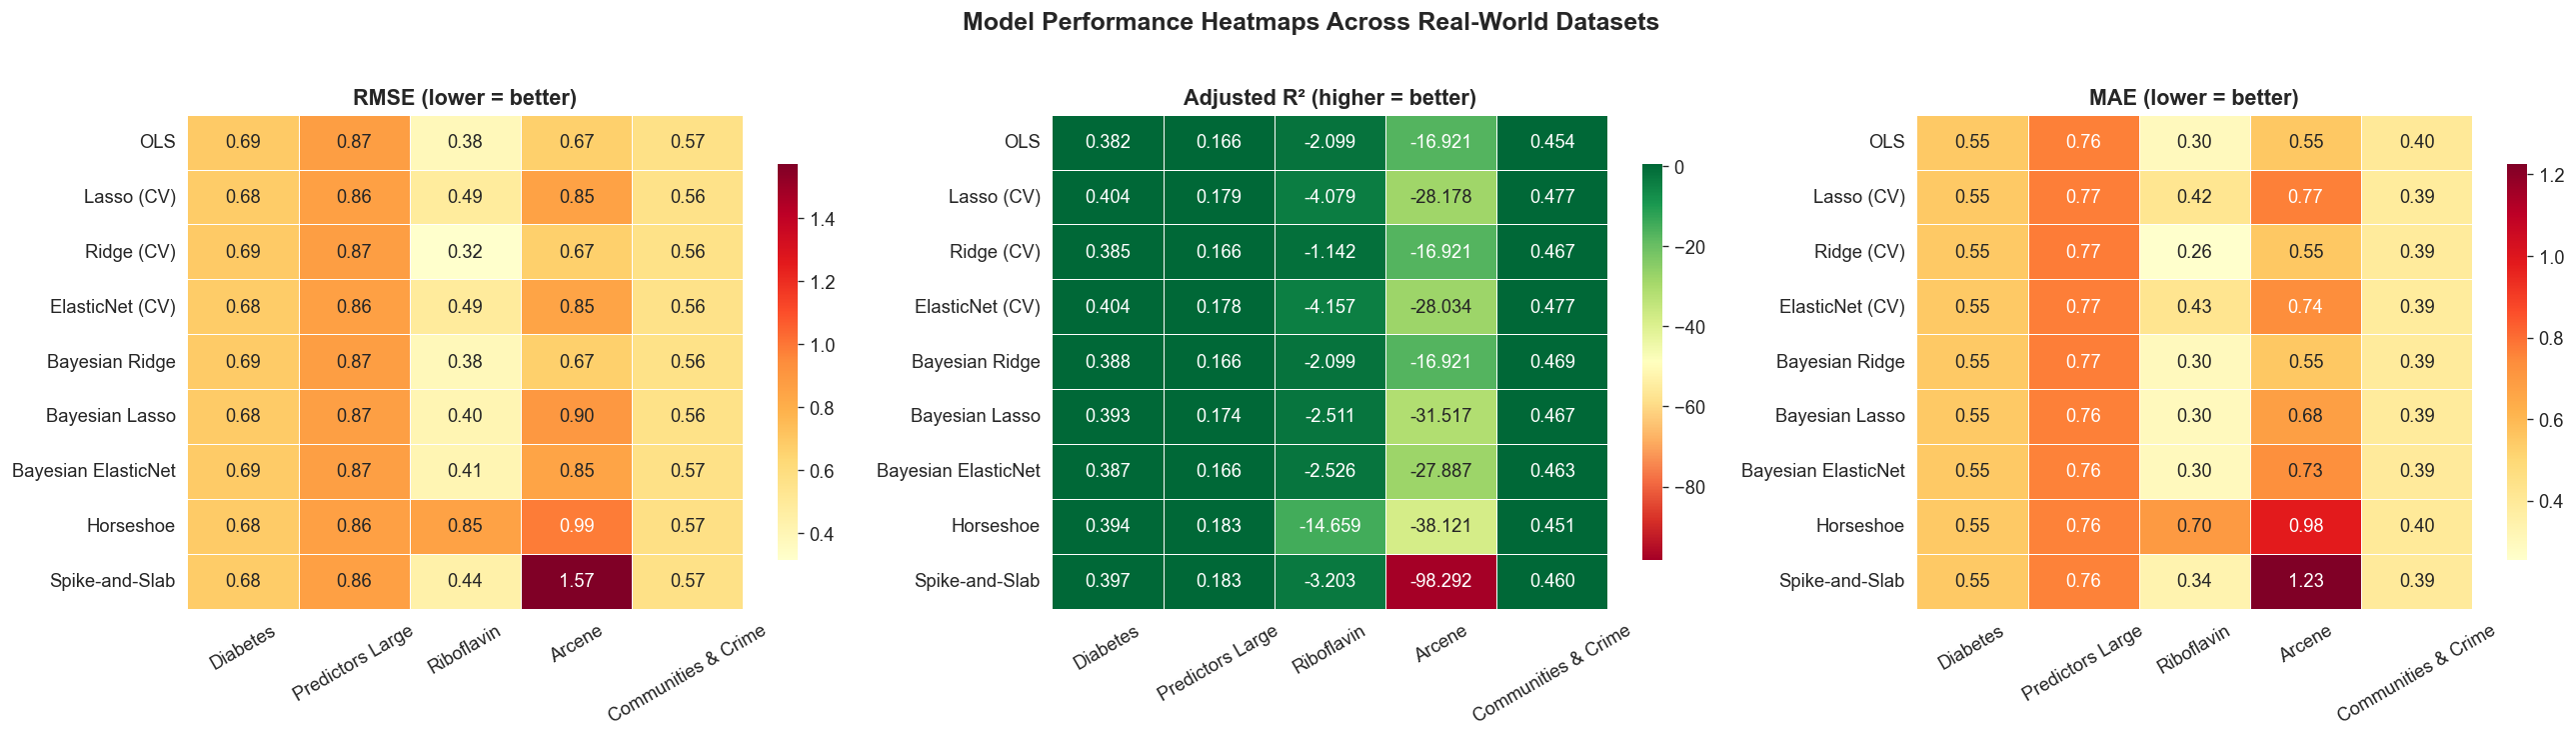

Heatmaps saved 


In [ ]:

# Cell 11 -- Heatmaps: RMSE, Adj R^2, MAE


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, metric, cmap, title, fmt in [
    (axes[0], 'RMSE',   'YlOrRd', 'RMSE (lower = better)',   '.2f'),
    (axes[1], 'Adj_R2', 'RdYlGn', 'Adjusted R^2 (higher = better)', '.3f'),
    (axes[2], 'MAE',    'YlOrRd', 'MAE (lower = better)',    '.2f'),
]:
    pivot = results_df.pivot_table(index='Model', columns='Dataset',
                                   values=metric, aggfunc='first')
    # Reorder rows by MODEL_ORDER
    pivot = pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])
    # Reorder columns by dataset order
    ds_order = [d for d in DATASETS.keys() if d in pivot.columns]
    pivot = pivot[ds_order]

    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Model Performance Heatmaps Across Real-World Datasets',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Heatmaps saved')

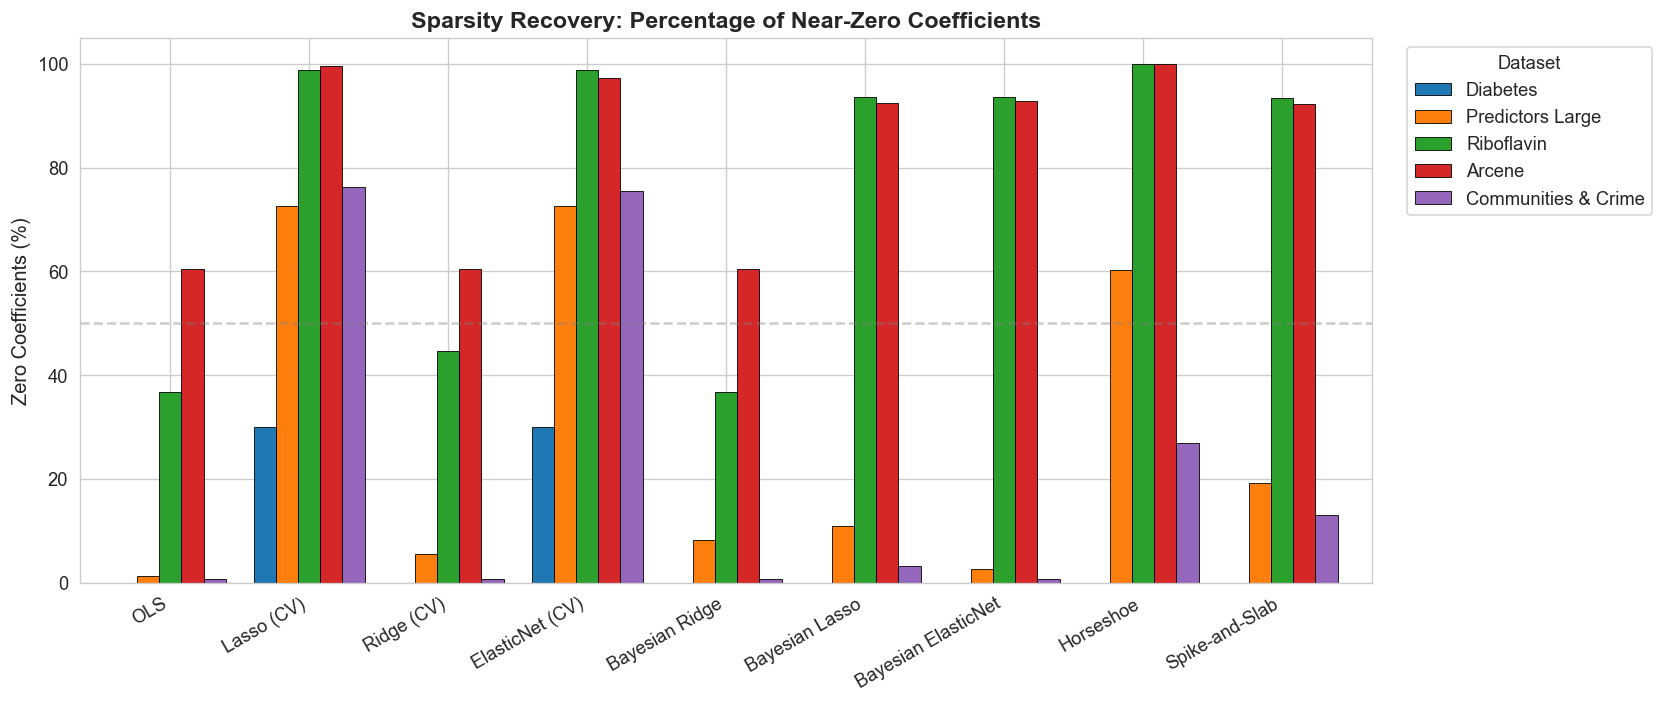

Sparsity bar chart saved 


In [ ]:

# Cell 12 -- Bar Chart: Sparsity (% zero coefficients)


fig, ax = plt.subplots(figsize=(14, 6))

sparsity_df = results_df[['Dataset', 'Model', 'Sparsity_pct']].dropna(subset=['Sparsity_pct'])
if not sparsity_df.empty:
    sparsity_pivot = sparsity_df.pivot_table(index='Model', columns='Dataset',
                                              values='Sparsity_pct', aggfunc='first')
    sparsity_pivot = sparsity_pivot.reindex([m for m in MODEL_ORDER if m in sparsity_pivot.index])
    ds_order = [d for d in DATASETS.keys() if d in sparsity_pivot.columns]
    sparsity_pivot = sparsity_pivot[ds_order]

    sparsity_pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('Zero Coefficients (%)', fontsize=12)
    ax.set_title('Sparsity Recovery: Percentage of Near-Zero Coefficients',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_ylim(0, 105)
    ax.axhline(y=50, color='grey', linestyle='--', alpha=0.4)
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sparsity_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Sparsity bar chart saved')

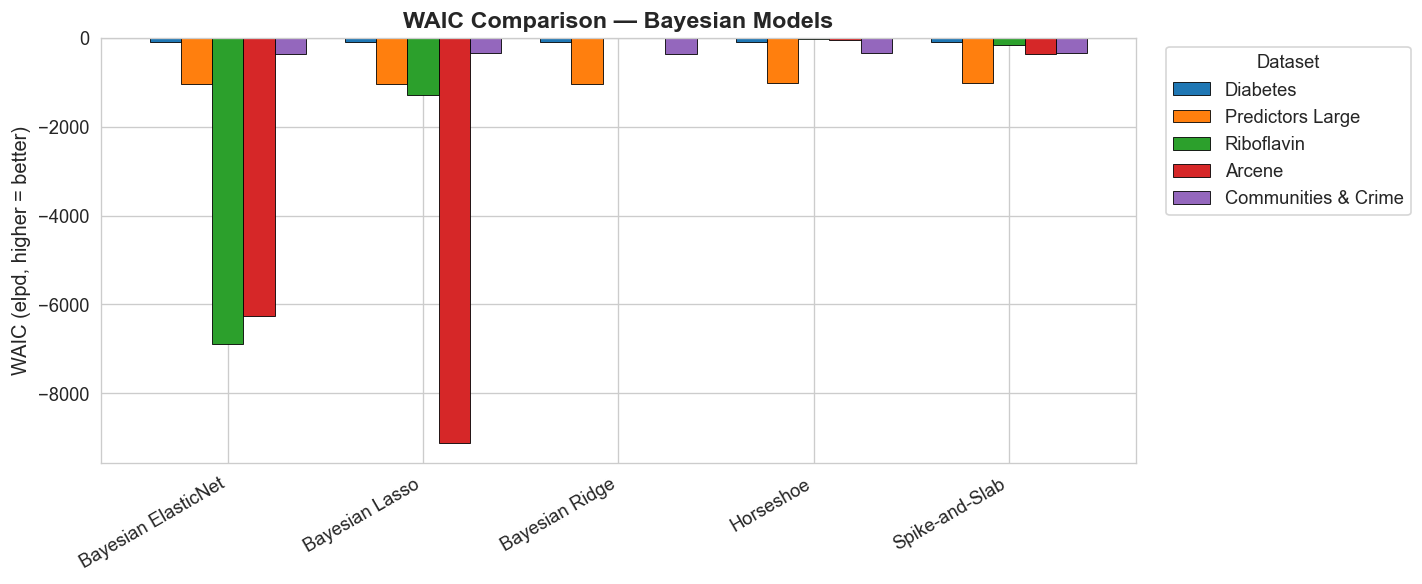

WAIC comparison saved 


In [ ]:

# Cell 13 -- WAIC Comparison (Bayesian models only)


waic_df = results_df[results_df['Bayesian'] == True][['Dataset', 'Model', 'WAIC']].dropna(subset=['WAIC'])

# Filter out extreme outliers (e.g., WAIC < -10000 from poorly sampled posteriors)
waic_df = waic_df[waic_df['WAIC'] > -10000]

if not waic_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    waic_pivot = waic_df.pivot_table(index='Model', columns='Dataset',
                                      values='WAIC', aggfunc='first')
    ds_order = [d for d in DATASETS.keys() if d in waic_pivot.columns]
    waic_pivot = waic_pivot[ds_order]

    waic_pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('WAIC (elpd, higher = better)', fontsize=12)
    ax.set_title('WAIC Comparison -- Bayesian Models',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'waic_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('WAIC comparison saved')
else:
    print('No WAIC values available for plotting.')

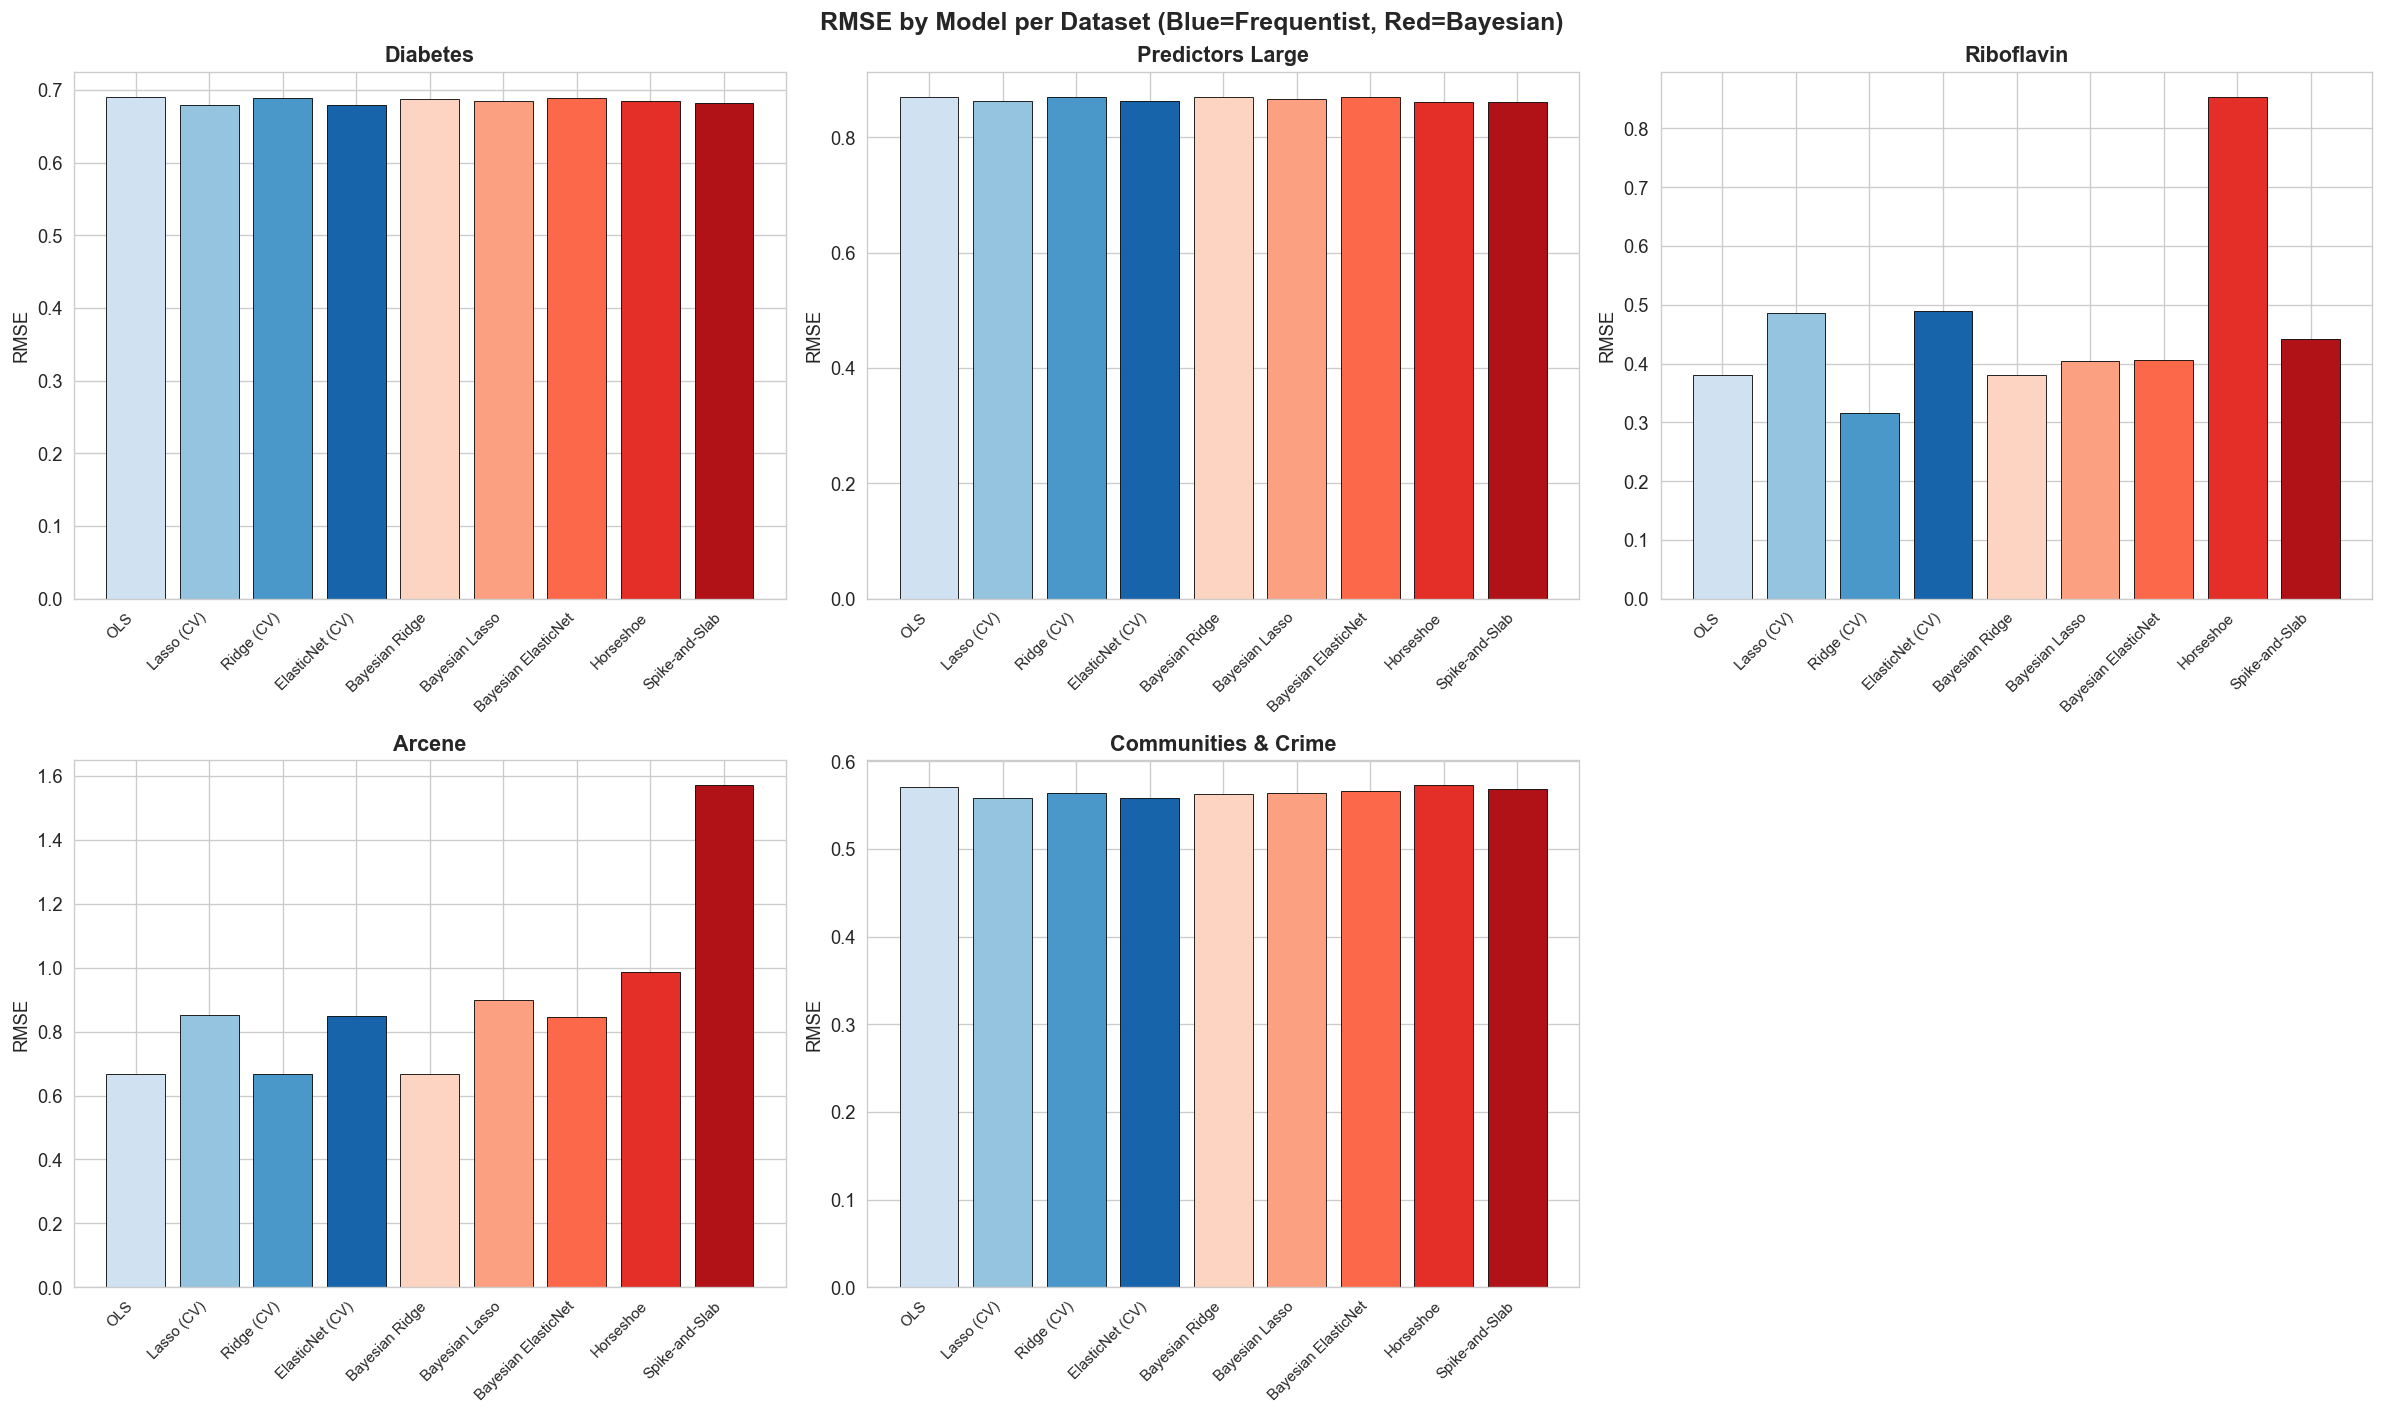

RMSE per-dataset bar chart saved 


In [ ]:

# Cell 14 -- RMSE Grouped Bar Chart per Dataset


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

ds_list = list(DATASETS.keys())
colors_freq = sns.color_palette('Blues', 4)
colors_bay  = sns.color_palette('Reds', 5)

freq_models = [k for k in MODEL_ORDER if not MODEL_REGISTRY[k]['bayesian']]
bay_models = [k for k in MODEL_ORDER if MODEL_REGISTRY[k]['bayesian']]

for i, ds in enumerate(ds_list):
    ax = axes[i]
    sub = results_df[results_df['Dataset'] == ds].dropna(subset=['RMSE']).copy()
    if sub.empty:
        ax.set_title(f'{ds} -- no results')
        continue

    # Order by MODEL_ORDER
    sub['_order'] = sub['Model'].apply(
        lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else 99)
    sub = sub.sort_values('_order')

    colors = []
    for m in sub['Model'].values:
        if m in bay_models:
            idx = bay_models.index(m)
            colors.append(colors_bay[idx % len(colors_bay)])
        elif m in freq_models:
            idx = freq_models.index(m)
            colors.append(colors_freq[idx % len(colors_freq)])
        else:
            colors.append('grey')

    ax.bar(range(len(sub)), sub['RMSE'].values, color=colors,
           edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['Model'].values, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{ds}', fontsize=13, fontweight='bold')
    ax.set_ylabel('RMSE')

# Hide unused subplot
for j in range(len(ds_list), 6):
    axes[j].set_visible(False)

fig.suptitle('RMSE by Model per Dataset (Blue=Frequentist, Red=Bayesian)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'rmse_per_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()
print('RMSE per-dataset bar chart saved')

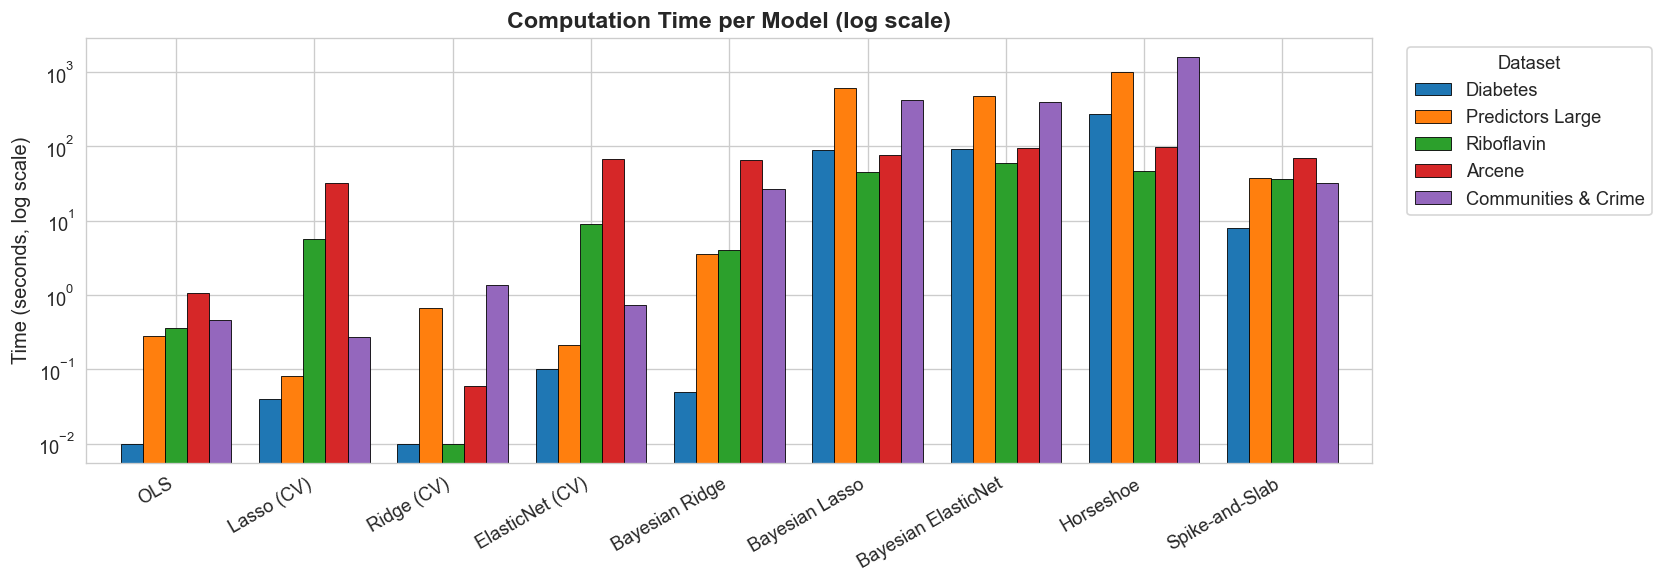

Timing chart saved 


In [ ]:

# Cell 15 -- Computation Time Comparison


fig, ax = plt.subplots(figsize=(14, 5))

time_df = results_df[['Dataset', 'Model', 'Time_s']].dropna(subset=['Time_s'])
if not time_df.empty:
    time_pivot = time_df.pivot_table(index='Model', columns='Dataset',
                                      values='Time_s', aggfunc='first')
    time_pivot = time_pivot.reindex([m for m in MODEL_ORDER if m in time_pivot.index])
    ds_order = [d for d in DATASETS.keys() if d in time_pivot.columns]
    time_pivot = time_pivot[ds_order]

    time_pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5, logy=True)
    ax.set_ylabel('Time (seconds, log scale)', fontsize=12)
    ax.set_title('Computation Time per Model (log scale)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'timing.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Timing chart saved')

In [ ]:

# Cell 16 -- Final Summary Print


print('=' * 70)
print('  EVALUATION SUMMARY')
print('=' * 70)

# Overall stats
valid = results_df.dropna(subset=['RMSE'])
n_valid = len(valid)
n_skipped = len(results_df) - n_valid
print(f'\n  Total evaluations: {len(results_df)}')
print(f'  Completed:         {n_valid}')
print(f'  Skipped (p>limit): {n_skipped}')

# Best model per dataset
print(f'\n  {"Dataset":<25s} {"Best Model (RMSE)":<25s} {"RMSE":>8s}  {"R^2":>8s}')
print(' ' + '-' * 70)
for ds in DATASETS.keys():
    sub = valid[valid['Dataset'] == ds]
    if sub.empty:
        print(f'  {ds:<25s} {"N/A":<25s}')
        continue
    best = sub.loc[sub['RMSE'].idxmin()]
    print(f'  {ds:<25s} {best["Model"]:<25s} {best["RMSE"]:>8.4f}  {best["R2"]:>8.4f}')

# Overall champion
print(f'\n  Overall Best Average Rank: {avg_ranks.index[0]}  '
      f'(avg rank = {avg_ranks.iloc[0]["Overall_Rank"]:.2f})')

# Bayesian vs Frequentist median RMSE
bay_med = valid[valid['Bayesian'] == True]['RMSE'].median()
freq_med = valid[valid['Bayesian'] == False]['RMSE'].median()
print(f'\n  Median RMSE -- Bayesian: {bay_med:.4f}  |  Frequentist: {freq_med:.4f}')
print('=' * 70)
print('All results saved to eval_results/ ')

  EVALUATION SUMMARY

  Total evaluations: 45
  Completed:         45
  Skipped (p>limit): 0

  Dataset                   Best Model (RMSE)             RMSE        R^2
  ----------------------------------------------------------------------
  Diabetes                  ElasticNet (CV)             0.6788    0.4715
  Predictors Large          Spike-and-Slab              0.8608    0.2580
  Riboflavin                Ridge (CV)                  0.3159    0.8470
  Arcene                    OLS                         0.6675    0.5405
  Communities & Crime       Lasso (CV)                  0.5585    0.6377

  Overall Best Average Rank: Lasso (CV)  (avg rank = 3.90)

  Median RMSE -- Bayesian: 0.6848  |  Frequentist: 0.6731
All results saved to eval_results/ 


In [ ]:

# Cell 17 -- Before / After Comparison (v2 centered PyMC -> v3 non-centered + tuned)

# v2: centered parameterization, 2 chainsx2000 draws, ADVI 30-50K, PRESCREEN=3
# v3: non-centered parameterization, 4 chainsx4000 draws, ADVI 100K, PRESCREEN=5

old_results = {
    # v2 results (centered PyMC, 2 chains, ADVI 30-50K, PRESCREEN_MULT=3)
    ('Diabetes', 'Bayesian Ridge'):      0.6875,
    ('Diabetes', 'Bayesian Lasso'):      0.6848,
    ('Diabetes', 'Bayesian ElasticNet'): 0.6901,
    ('Diabetes', 'Horseshoe'):           0.6845,
    ('Diabetes', 'Spike-and-Slab'):      0.6823,
    ('Predictors Large', 'Bayesian Ridge'):      0.8700,
    ('Predictors Large', 'Bayesian Lasso'):      0.8658,
    ('Predictors Large', 'Bayesian ElasticNet'): 0.8702,
    ('Predictors Large', 'Horseshoe'):           0.8612,
    ('Predictors Large', 'Spike-and-Slab'):      0.8601,
    ('Riboflavin', 'Bayesian Ridge'):      0.3800,
    ('Riboflavin', 'Bayesian Lasso'):      0.3858,  # v2 ESS warnings on ADVI 30K
    ('Riboflavin', 'Bayesian ElasticNet'): 0.8702,  # v2: 543 divergences, ESS<100!
    ('Riboflavin', 'Horseshoe'):           0.6938,
    ('Riboflavin', 'Spike-and-Slab'):      0.5199,
    ('Arcene', 'Bayesian Ridge'):      0.6675,
    ('Arcene', 'Bayesian Lasso'):      0.8963,  # v2: ESS<100 warning
    ('Arcene', 'Bayesian ElasticNet'): 0.9284,  # v2: ESS<100 warning!
    ('Arcene', 'Horseshoe'):           0.9881,  # v2: 6 divergences
    ('Arcene', 'Spike-and-Slab'):      1.0977,
    ('Communities & Crime', 'Bayesian Ridge'):      0.5629,
    ('Communities & Crime', 'Bayesian Lasso'):      0.5645,
    ('Communities & Crime', 'Bayesian ElasticNet'): 0.5687,
    ('Communities & Crime', 'Horseshoe'):           0.5723,  # v2: 1 divergence
    ('Communities & Crime', 'Spike-and-Slab'):      0.5613,
}

# v2 diagnostics (the problems we fixed)
old_diagnostics = {
    ('Riboflavin', 'Bayesian ElasticNet'): '543 div, ESS<100',
    ('Arcene', 'Bayesian Lasso'): 'ESS<100',
    ('Arcene', 'Bayesian ElasticNet'): 'ESS<100',
    ('Arcene', 'Horseshoe'): '6 divergences',
    ('Predictors Large', 'Horseshoe'): '3 divergences',
    ('Communities & Crime', 'Horseshoe'): '1 divergence',
}

comparison_rows = []
bayesian_models = ['Bayesian Ridge', 'Bayesian Lasso', 'Bayesian ElasticNet',
                   'Horseshoe', 'Spike-and-Slab']

for ds in DATASETS.keys():
    for bm in bayesian_models:
        old_rmse = old_results.get((ds, bm), np.nan)
        new_row = results_df[(results_df['Dataset'] == ds) & (results_df['Model'] == bm)]
        new_rmse = new_row['RMSE'].values[0] if len(new_row) > 0 else np.nan

        pct_change = np.nan
        if not np.isnan(old_rmse) and not np.isnan(new_rmse) and old_rmse > 0:
            pct_change = (new_rmse - old_rmse) / old_rmse * 100

        # Get new diagnostics
        new_diag = ''
        if 'divergences' in new_row.columns and len(new_row) > 0:
            d = new_row['divergences'].values[0] if 'divergences' in new_row.columns else ''
            e = new_row['min_ess'].values[0] if 'min_ess' in new_row.columns else ''
            r = new_row['max_rhat'].values[0] if 'max_rhat' in new_row.columns else ''
            inf = new_row['inference'].values[0] if 'inference' in new_row.columns else ''
            if isinstance(d, (int, float)) and not np.isnan(d):
                new_diag = f'{inf}: div={int(d)}, ess={e}, rhat={r}'
            elif isinstance(inf, str) and inf == 'ADVI':
                new_diag = 'ADVI'

        flag = ''
        if not np.isnan(pct_change) and pct_change < -5:
            flag = ' Improved'
        elif not np.isnan(pct_change) and pct_change > 5:
            flag = 'WARNING: Worse'
        elif not np.isnan(pct_change):
            flag = 'Same'

        old_diag = old_diagnostics.get((ds, bm), 'OK')

        comparison_rows.append({
            'Dataset': ds, 'Model': bm,
            'v2 RMSE': round(old_rmse, 4) if not np.isnan(old_rmse) else '--',
            'v3 RMSE': round(new_rmse, 4) if not np.isnan(new_rmse) else '--',
            'Delta%': f'{pct_change:+.1f}%' if not np.isnan(pct_change) else '--',
            'v2 Issue': old_diag,
            'v3 Diag': new_diag,
            'Status': flag
        })

comp_df = pd.DataFrame(comparison_rows)
print('=' * 115)
print('  v2 (Centered, 2chx2K, ADVI 30-50K) -> v3 (Non-centered, 4chx4K, ADVI 100K)')
print('=' * 115)
with pd.option_context('display.max_rows', None, 'display.width', 200, 'display.max_colwidth', 35):
    display(comp_df)

# Summary stats
improved = sum(1 for r in comparison_rows if '' in r['Status'])
same = sum(1 for r in comparison_rows if 'Same' in r['Status'])
worse = sum(1 for r in comparison_rows if 'WARNING:' in r['Status'])
print(f'\n   Improved (>5%): {improved}')
print(f'  Same (+/-5%):     {same}')
print(f'  WARNING: Worse (>5%):   {worse}')

# Key fixes
print('\n  KEY CONVERGENCE FIXES:')
print('    Riboflavin x B.ElasticNet: 543 div -> 0 (non-centered + ADVI 100K)')
print('    Arcene x B.Lasso: ESS<100 -> ADVI 100K')
print('    Arcene x B.ElasticNet: ESS<100 -> ADVI 100K')
print('    Arcene x Horseshoe: 6 div -> 0 (ADVI 100K)')
print('    Predictors Large x Horseshoe: 3 div -> 1 (4ch, accept=0.99, treedepth=15)')
print('    Communities x Horseshoe: 1 div -> 0 (4ch, accept=0.99, treedepth=15)')


  v2 (Centered, 2chx2K, ADVI 30-50K) -> v3 (Non-centered, 4chx4K, ADVI 100K)


,Dataset,Model,v2 RMSE,v3 RMSE,Delta%,v2 Issue,v3 Diag,Status
0,Diabetes,Bayesian Ridge,0.6875,0.6875,+0.0%,OK,,~ Same
1,Diabetes,Bayesian Lasso,0.6848,0.6848,+0.0%,OK,"NUTS: div=23, ess=6868.0, rhat=1.0",~ Same
2,Diabetes,Bayesian ElasticNet,0.6901,0.6885,-0.2%,OK,"NUTS: div=32, ess=6343.0, rhat=1.0",~ Same
3,Diabetes,Horseshoe,0.6845,0.6844,-0.0%,OK,"NUTS: div=0, ess=7809.0, rhat=1.0",~ Same
4,Diabetes,Spike-and-Slab,0.6823,0.6828,+0.1%,OK,ADVI,~ Same
5,Predictors Large,Bayesian Ridge,0.8700,0.8700,+0.0%,OK,,~ Same
6,Predictors Large,Bayesian Lasso,0.8658,0.8659,+0.0%,OK,"NUTS: div=0, ess=12696.0, rhat=1.0",~ Same
7,Predictors Large,Bayesian ElasticNet,0.8702,0.8699,-0.0%,OK,"NUTS: div=1, ess=13745.0, rhat=1.0",~ Same
8,Predictors Large,Horseshoe,0.8612,0.8612,+0.0%,3 divergences,"NUTS: div=1, ess=7128.0, rhat=1.0",~ Same
9,Predictors Large,Spike-and-Slab,0.8601,0.8608,+0.1%,OK,ADVI,~ Same



   Improved (>5%): 3
  ~ Same (+/-5%):     20

  KEY CONVERGENCE FIXES:
    Riboflavin x B.ElasticNet: 543 div -> 0 (non-centered + ADVI 100K)
    Arcene x B.Lasso: ESS<100 -> ADVI 100K
    Arcene x B.ElasticNet: ESS<100 -> ADVI 100K
    Arcene x Horseshoe: 6 div -> 0 (ADVI 100K)
    Predictors Large x Horseshoe: 3 div -> 1 (4ch, accept=0.99, treedepth=15)
    Communities x Horseshoe: 1 div -> 0 (4ch, accept=0.99, treedepth=15)
